<center><img src="img/Marca-ITBA-Color-ALTA.png" width="250">

<center>
  <h1>Trabajo Final - Deep Learning</h1>
  <h2>Predicción de admisiones en la guardia de un hospital</h2>
  <h4>Master en Management & Analytics</h4>
  <h4>Alumno: Camila Zaffar</h4>
</center>

## 1. Introducción

La planificación de recursos en los servicios de urgencias constituye uno de los principales desafíos de la gestión hospitalaria. La demanda diaria de atención presenta una alta variabilidad, influenciada por factores temporales, climáticos y estacionales, lo que dificulta la asignación eficiente de personal, camas e insumos. Como consecuencia, una estimación imprecisa de la demanda puede derivar en situaciones de saturación, mayores tiempos de espera y una disminución en la calidad del servicio.

En este contexto, la cantidad diaria de admisiones puede utilizarse como una **proxy de la demanda asistencial**, permitiendo anticipar las necesidades de recursos humanos, infraestructura e insumos para mejorar la planificación operativa del hospital.

El forecasting de series temporales constituye una herramienta de apoyo para la toma de decisiones, ya que permite estimar la demanda esperada con anticipación y facilitar la asignación de recursos. Sin embargo, la incorporación de modelos cada vez más complejos solo resulta justificada si produce mejoras significativas respecto de enfoques más simples.

El objetivo de este trabajo es desarrollar y comparar distintos modelos para pronosticar la cantidad diaria de admisiones al servicio de guardia de un hospital con un horizonte de hasta siete días. Para ello, se evalúan un modelo **baseline Naive**, modelos estadísticos clásicos (ARIMA y Prophet) y arquitecturas de Deep Learning (LSTM y Transformer), utilizando tanto información histórica de admisiones como variables exógenas relacionadas con el calendario y las condiciones meteorológicas.

La comparación entre estos enfoques permitirá determinar si el incremento en la complejidad de los modelos de Deep Learning se traduce en mejoras significativas respecto del modelo baseline y de los métodos estadísticos tradicionales, identificando la alternativa más adecuada para asistir la planificación operativa hospitalaria.

## 2. Dataset

Se utiliza el dataset público **Emergency Department Forecasting Dataset**, publicado por Peláez-Rodríguez et al. (2024), que contiene registros diarios de admisiones a la guardia de un hospital de Madrid.

El conjunto de datos posee:

- 1.478 observaciones diarias.
- Período comprendido entre septiembre de 2018 y septiembre de 2022.
- Sin valores faltantes.
- Esquema de predicción multi-step ya preparado.

Las variables pueden agruparse en cuatro categorías principales:

- **Variables temporales:** día de la semana, feriados y fase lunar.
- **Variables meteorológicas:** temperatura, viento, presión atmosférica y precipitaciones.
- **Variables autorregresivas:** admisiones observadas durante los siete días previos (ED_1 a ED_7).
- **Variables objetivo:** cantidad de admisiones para cada uno de los siete días futuros (Target_1 a Target_7).

In [1]:
# Se importan librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### 2.1. Análisis Exploratorio de Datos

Como primera etapa del desarrollo, se realizó un análisis exploratorio del conjunto de datos con el objetivo de comprender las características de la serie temporal e identificar patrones relevantes para el modelado. En esta sección se analiza la estructura del dataset, la calidad de los datos y el comportamiento de las admisiones diarias, evaluando aspectos como su distribución, tendencia, estacionalidad y dependencia temporal.

In [2]:
# Se importa el dataset
df = pd.read_csv("data/Madrid_database.csv", sep=",")

In [3]:
# Se convierten las fechas a formato datetime y se ordena el dataframe por fecha
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df = df.sort_values("Date").reset_index(drop=True)

In [4]:
df.head()

,Date,Day_of_week,Holiday,Moon_Phase,Average_Temp,Max_temp,Average_wind,Max_wind,Average_mslp,Total_precipitation,...,ED_5,ED_6,ED_7,Target_1,Target_2,Target_3,Target_4,Target_5,Target_6,Target_7
0,2018-09-08,6,0,5,295.01,299.30,2.56,3.96,101703.64,0.00281,...,20.0,13.0,11.0,12,16.0,21.0,14.0,14.0,17.0,19.0
1,2018-09-09,7,0,1,295.68,302.16,1.26,3.03,101901.04,0.00012,...,14.0,20.0,13.0,16,21.0,14.0,14.0,17.0,19.0,17.0
2,2018-09-10,1,0,0,296.24,302.14,2.44,3.57,102190.41,0.00014,...,14.0,14.0,20.0,21,14.0,14.0,17.0,19.0,17.0,19.0
3,2018-09-11,2,0,1,296.40,303.19,2.36,3.57,102223.68,0.00139,...,14.0,14.0,14.0,14,14.0,17.0,19.0,17.0,19.0,22.0
4,2018-09-12,3,0,4,297.18,303.88,1.39,2.95,102153.50,0.00001,...,12.0,14.0,14.0,14,17.0,19.0,17.0,19.0,22.0,15.0


In [5]:
print(f"Shape: {df.shape}")
print(f"Rango de fechas: {df['Date'].min().date()} a {df['Date'].max().date()}")
print(f"Valores faltantes totales: {df.isna().sum().sum()}")

Shape: (1478, 25)
Rango de fechas: 2018-09-08 a 2022-09-24
Valores faltantes totales: 0


In [6]:
# Se muestran estadísticas descriptivas del dataframe
df.describe()

,Date,Day_of_week,Holiday,Moon_Phase,Average_Temp,Max_temp,Average_wind,Max_wind,Average_mslp,Total_precipitation,...,ED_5,ED_6,ED_7,Target_1,Target_2,Target_3,Target_4,Target_5,Target_6,Target_7
count,1478,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,...,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000,1478.000000
mean,2020-09-15 12:00:00.000000256,4.001353,0.037889,49.959405,288.966299,294.904899,2.607558,4.150575,101785.162152,0.001287,...,43.820027,43.769283,43.731394,43.989175,44.039242,44.080514,44.121786,44.152909,44.181326,44.210419
min,2018-09-08 00:00:00,1.000000,0.000000,0.000000,270.800000,274.290000,0.770000,1.340000,99530.020000,0.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000
25%,2019-09-12 06:00:00,2.000000,0.000000,15.000000,282.392500,287.200000,1.780000,2.922500,101359.587500,0.000000,...,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000,28.000000
50%,2020-09-15 12:00:00,4.000000,0.000000,50.000000,287.510000,293.520000,2.380000,3.950000,101692.005000,0.000010,...,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
75%,2021-09-19 18:00:00,6.000000,0.000000,85.000000,295.710000,302.380000,3.217500,5.187500,102170.707500,0.000740,...,57.000000,57.000000,57.000000,57.750000,58.000000,58.000000,58.000000,58.000000,58.000000,58.000000
max,2022-09-24 00:00:00,7.000000,1.000000,100.000000,306.040000,314.590000,8.280000,11.300000,103423.980000,0.037580,...,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000,141.000000
std,NaN,2.000676,0.190993,35.398185,8.086503,9.029700,1.134683,1.597149,632.236010,0.003410,...,20.070022,20.053050,20.062029,20.037775,20.050237,20.055262,20.070493,20.059415,20.046415,20.038142


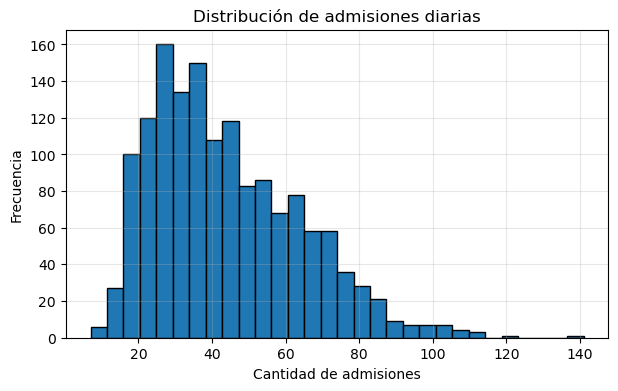

In [7]:
plt.figure(figsize=(7,4))

plt.hist(df["ED_1"], bins=30, edgecolor="black")

plt.title("Distribución de admisiones diarias")
plt.xlabel("Cantidad de admisiones")
plt.ylabel("Frecuencia")

plt.grid(alpha=0.3)
plt.show()

La distribución de las admisiones diarias presenta una asimetría positiva, con una mayor concentración de observaciones entre aproximadamente 20 y 50 admisiones por día y una cola hacia valores elevados. Esto indica que, aunque la demanda habitual se mantiene en niveles moderados, existen jornadas con un volumen de admisiones considerablemente superior al promedio. La ausencia de una distribución normal perfecta indica que el modelo deberá ser capaz de capturar tanto el comportamiento habitual como episodios de alta demanda.

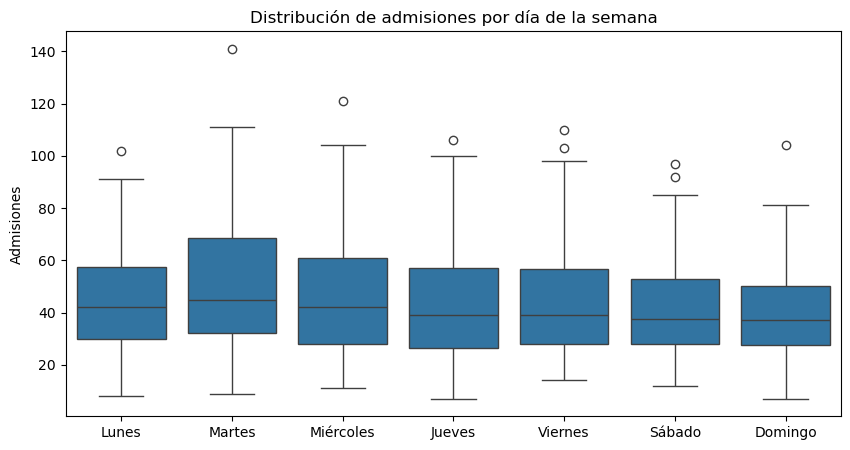

In [8]:
dias = [
    "Lunes","Martes","Miércoles",
    "Jueves","Viernes","Sábado","Domingo"
]

temp = df.copy()
temp["Dia"] = temp["Day_of_week"].map(dict(zip(range(1,8), dias)))

plt.figure(figsize=(10,5))

sns.boxplot(
    data=temp,
    x="Dia",
    y="ED_1",
    order=dias
)

plt.suptitle("")
plt.title("Distribución de admisiones por día de la semana")
plt.xlabel("")
plt.ylabel("Admisiones")

plt.show()

El gráfico boxplot muestra la distribución de las admisiones con leves diferencias entre los distintos días de la semana. En particular, los martes muestran una mediana ligeramente superior y una mayor dispersión, mientras que durante el fin de semana las admisiones tienden a ser algo menores. A su vez, se observan valores atípicos o outliers en prácticamente todos los días, lo que evidencia la existencia de jornadas con una demanda excepcionalmente alta. Estos resultados sugieren la presencia de un componente semanal que resulta conveniente incorporar en el proceso de modelado.

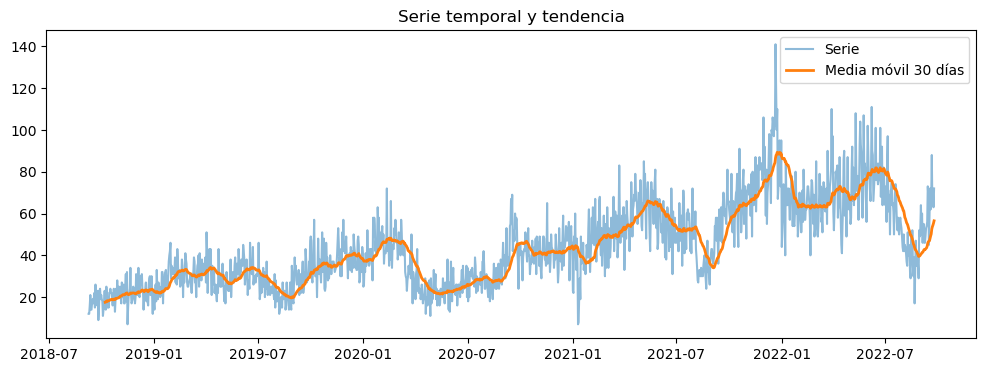

In [9]:
plt.figure(figsize=(12,4))

plt.plot(df["Date"], df["ED_1"],
         alpha=0.5,
         label="Serie")

plt.plot(df["Date"],
         df["ED_1"].rolling(30).mean(),
         linewidth=2,
         label="Media móvil 30 días")

plt.legend()
plt.title("Serie temporal y tendencia")
plt.show()

La serie temporal evidencia una tendencia creciente en la cantidad de admisiones a lo largo del período analizado, acompañada de fluctuaciones de corto plazo. La media móvil de 30 días permite apreciar con mayor claridad esta evolución, mostrando incrementos progresivos y algunos descensos transitorios, como lo fue en el período de COVID-19, antes de retomar la tendencia ascendente. La presencia simultánea de tendencia y variabilidad temporal indica que la demanda hospitalaria no es estacionaria, por lo que refuerza la necesidad de utilizar modelos capaces de capturar estas dinámicas.

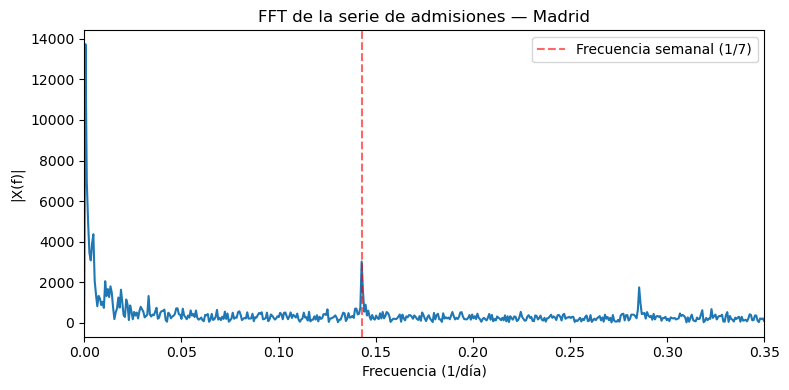

In [10]:
# Análisis de la serie temporal mediante la Transformada Rápida de Fourier (FFT)
from numpy.fft import fft, fftfreq

y = df["ED_1"].values
y_detrended = y - y.mean()
n = len(y_detrended)
yf = np.abs(fft(y_detrended))[: n // 2]
xf = fftfreq(n, d=1)[: n // 2]

plt.figure(figsize=(8, 4))
plt.plot(xf, yf)
plt.xlim(0, 0.35)
plt.xlabel("Frecuencia (1/día)")
plt.ylabel("|X(f)|")
plt.title("FFT de la serie de admisiones — Madrid")
plt.axvline(1 / 7, color="red", linestyle="--", alpha=0.6, label="Frecuencia semanal (1/7)")
plt.legend()
plt.tight_layout()
plt.show()

El patrón estacional visto en la serie temporal se confirma mediante la Transformada Rápida de Fourier (FFT), que presenta un pico dominante en la frecuencia correspondiente a un ciclo semanal (1/7 días). En conjunto, ambos análisis indican que la demanda hospitalaria posee una marcada componente temporal, por lo que resulta razonable utilizar modelos capaces de capturar tanto tendencias como dependencias estacionales para realizar los pronósticos.

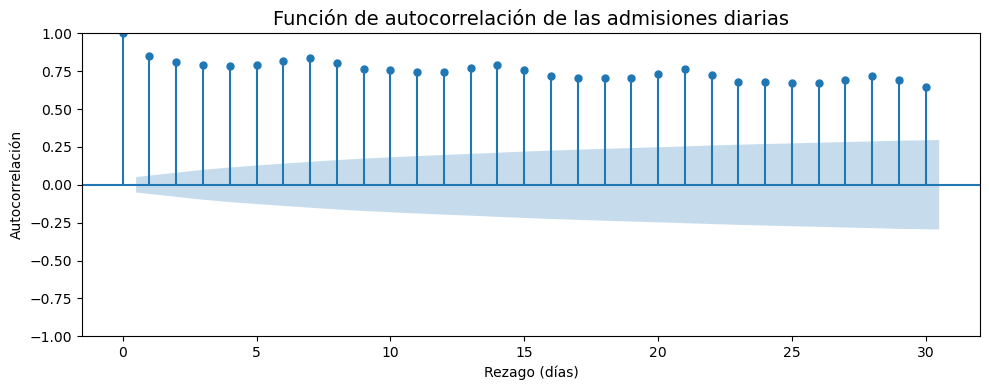

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 4))

plot_acf(df["ED_1"], lags=30, ax=ax)

ax.set_title("Función de autocorrelación de las admisiones diarias", fontsize=14)
ax.set_xlabel("Rezago (días)")
ax.set_ylabel("Autocorrelación")

plt.tight_layout()
plt.show()

La función de autocorrelación muestra cuán relacionada está la cantidad de admisiones del día posterior con los 30 días previos. En el gráfico se pueden observar coeficientes elevados y estadísticamente significativos para los 30 días previos analizados, indicando una fuerte dependencia temporal entre las observaciones. La autocorrelación disminuye lentamente a medida que aumenta el rezago, lo cual confirma que las admisiones de días anteriores contienen información relevante para predecir la demanda futura. Este comportamiento respalda el uso de modelos de series temporales y arquitecturas de aprendizaje profundo, como las redes LSTM, capaces de explotar dependencias de largo alcance.

## 3. Preprocesamiento

Una vez realizado el análisis exploratorio, se aplicaron las transformaciones necesarias para preparar los datos para el entrenamiento de los modelos. El objetivo de esta etapa es construir un conjunto de datos consistente, preservar la estructura temporal de la serie y adaptar las variables a los requerimientos de cada algoritmo, evitando sesgos durante la evaluación.

### 3.1. Feature Engineering

Como parte del proceso de feature engineering, se transformaron algunas variables temporales para representar correctamente su naturaleza cíclica.

En particular, las variables **Day_of_week** y **Moon_Phase** fueron codificadas mediante funciones seno y coseno. Esta representación evita que los modelos interpreten dichas variables como ordinales y preserva la continuidad de sus ciclos. De esta manera, por ejemplo, el domingo y el lunes quedan representados como días consecutivos, al igual que las distintas fases de la luna dentro de su ciclo.

In [12]:
# Día de la semana
df["Day_sin"] = np.sin(2 * np.pi * df["Day_of_week"] / 7)
df["Day_cos"] = np.cos(2 * np.pi * df["Day_of_week"] / 7)

# Fase lunar
n_moon = df["Moon_Phase"].nunique()

df["Moon_sin"] = np.sin(2 * np.pi * df["Moon_Phase"] / n_moon)
df["Moon_cos"] = np.cos(2 * np.pi * df["Moon_Phase"] / n_moon)

In [13]:
df.drop(
    columns=["Day_of_week", "Moon_Phase"],
    inplace=True
)

In [14]:
df[
    [
        "Day_sin",
        "Day_cos",
        "Moon_sin",
        "Moon_cos"
    ]
].head()

,Day_sin,Day_cos,Moon_sin,Moon_cos
0,-7.818315e-01,0.623490,0.306057,0.952013
1,-2.449294e-16,1.000000,0.062170,0.998066
2,7.818315e-01,0.623490,0.000000,1.000000
3,9.749279e-01,-0.222521,0.062170,0.998066
4,4.338837e-01,-0.900969,0.246279,0.969199


### 3.2. Split cronológico de los datos

Dado que se trabaja con una serie temporal, el conjunto de datos no puede dividirse de forma aleatoria, ya que ello introduciría información futura en el entrenamiento (*data leakage*) y produciría una evaluación poco realista.

Por este motivo, las observaciones se particionaron respetando el orden cronológico, destinando el **70%** de los datos al entrenamiento, el **15%** a validación y el **15%** restante a test.

El conjunto de entrenamiento se utilizó para ajustar los parámetros de los modelos, el de validación para más adelante seleccionar hiperparámetros y monitorear el entrenamiento, y el conjunto de test se reservó exclusivamente para evaluar el desempeño final. Esta estrategia reproduce el escenario real de pronóstico, donde las predicciones se realizan únicamente a partir de información histórica disponible.

In [15]:
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15

n = len(df)

train_end = int(n * TRAIN_SIZE)
val_end = int(n * (TRAIN_SIZE + VAL_SIZE))

train_df = df.iloc[:train_end].reset_index(drop=True)
val_df = df.iloc[train_end:val_end].reset_index(drop=True)
test_df = df.iloc[val_end:].reset_index(drop=True)

print(f"Total de observaciones: {n}\n")

print(f"Train:      {len(train_df):4d} filas ({len(train_df)/n:.1%})")
print(f"Validation: {len(val_df):4d} filas ({len(val_df)/n:.1%})")
print(f"Test:       {len(test_df):4d} filas ({len(test_df)/n:.1%})")

Total de observaciones: 1478

Train:      1034 filas (70.0%)
Validation:  222 filas (15.0%)
Test:        222 filas (15.0%)


La siguiente figura muestra la partición cronológica del conjunto de datos. Se observa que las tres particiones corresponden a intervalos temporales consecutivos, evitando el solapamiento entre entrenamiento, validación y test y garantizando que los modelos sean evaluados sobre información no utilizada durante su entrenamiento.

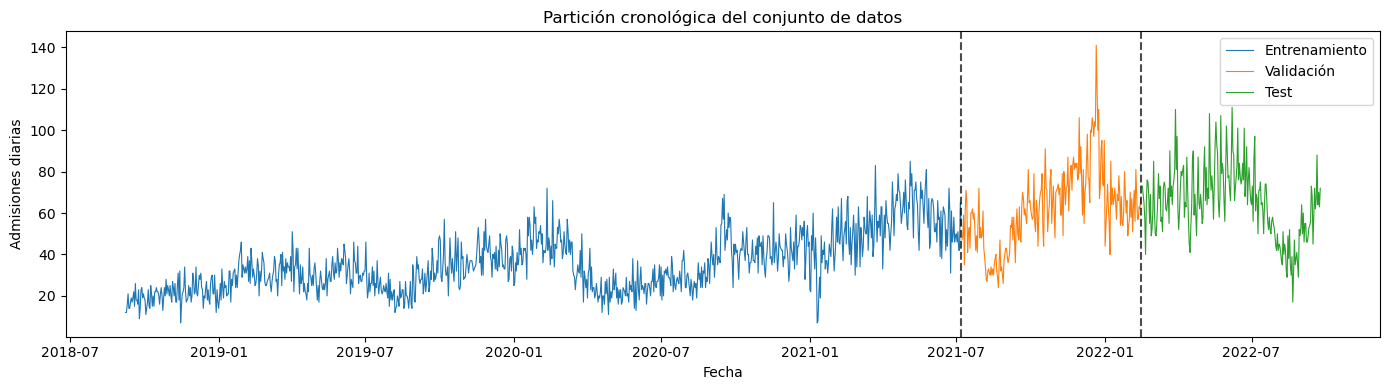

In [16]:
plt.figure(figsize=(14, 4))

plt.plot(train_df["Date"], train_df["ED_1"],
         label="Entrenamiento", linewidth=0.8)

plt.plot(val_df["Date"], val_df["ED_1"],
         label="Validación", linewidth=0.8)

plt.plot(test_df["Date"], test_df["ED_1"],
         label="Test", linewidth=0.8)

# Líneas verticales que marcan las divisiones
plt.axvline(train_df["Date"].iloc[-1], color="black", linestyle="--", alpha=0.7)
plt.axvline(val_df["Date"].iloc[-1], color="black", linestyle="--", alpha=0.7)

plt.title("Partición cronológica del conjunto de datos")
plt.xlabel("Fecha")
plt.ylabel("Admisiones diarias")
plt.legend()
plt.tight_layout()
plt.show()

### 3.3. Estandarización de las variables predictoras

Con el objetivo de evitar que las diferencias de escala entre las variables influyan en el entrenamiento de los modelos, las variables predictoras numéricas fueron estandarizadas mediante **StandardScaler**, obteniendo variables con media cero y desvío estándar uno.

El escalador se ajustó exclusivamente con el conjunto de entrenamiento y posteriormente se aplicó a los conjuntos de validación y prueba. De esta forma, se evita la incorporación de información futura (*data leakage*) y se garantiza una evaluación consistente de los modelos.

La estandarización resulta especialmente importante para las arquitecturas de Deep Learning, ya que favorece una convergencia más estable y eficiente durante el proceso de optimización.

In [17]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "Day_sin",
    "Day_cos",
    "Holiday",
    "Moon_sin",
    "Moon_cos",
    "Average_Temp",
    "Max_temp",
    "Average_wind",
    "Max_wind",
    "Average_mslp",
    "Total_precipitation",
    "Holiday_prev",
    "ED_1",
    "ED_2",
    "ED_3",
    "ED_4",
    "ED_5",
    "ED_6",
    "ED_7",
]

# Ajustar únicamente con entrenamiento
scaler_X = StandardScaler()
scaler_X.fit(train_df[feature_cols])

# Transformar cada partición
X_train = pd.DataFrame(
    scaler_X.transform(train_df[feature_cols]),
    columns=feature_cols
)

X_val = pd.DataFrame(
    scaler_X.transform(val_df[feature_cols]),
    columns=feature_cols
)

X_test = pd.DataFrame(
    scaler_X.transform(test_df[feature_cols]),
    columns=feature_cols
)

print(f"Train:      {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test:       {X_test.shape}")

X_train.head()

Train:      (1034, 19)
Validation: (222, 19)
Test:       (222, 19)


,Day_sin,Day_cos,Holiday,Moon_sin,Moon_cos,Average_Temp,Max_temp,Average_wind,Max_wind,Average_mslp,Total_precipitation,Holiday_prev,ED_1,ED_2,ED_3,ED_4,ED_5,ED_6,ED_7
0,-1.107754,0.880094,-0.205764,0.500391,0.913940,0.881229,0.612730,-0.075744,-0.119399,-0.133470,0.433564,-0.205764,-1.688954,-1.541769,-1.539832,-1.536293,-1.102492,-1.602300,-1.741560
1,-0.001927,1.412489,-0.205764,0.112998,0.978025,0.968019,0.941968,-1.144778,-0.674441,0.167042,-0.360968,-0.205764,-1.688954,-1.685681,-1.539832,-1.536293,-1.534029,-1.099157,-1.597975
2,1.103900,0.880094,-0.205764,0.014247,0.980717,1.040561,0.939666,-0.174424,-0.352158,0.607565,-0.355061,-0.205764,-1.401046,-1.685681,-1.683895,-1.536293,-1.534029,-1.530423,-1.095427
3,1.377017,-0.316187,-0.205764,0.112998,0.978025,1.061287,1.060540,-0.240211,-0.352158,0.658214,0.014146,-0.205764,-1.041161,-1.397857,-1.683895,-1.680207,-1.534029,-1.530423,-1.526183
4,0.611761,-1.275529,-0.205764,0.405438,0.937855,1.162326,1.139972,-1.037874,-0.722186,0.551375,-0.393458,-0.205764,-1.545000,-1.038076,-1.395769,-1.680207,-1.677874,-1.530423,-1.526183


## 4. Entrenamiento de modelos

### 4.1. Definición del problema de predicción y metodología de evaluación

El problema se plantea como un pronóstico con un horizonte de siete días. Para ello, se definieron siete variables objetivo (`Target_1` a `Target_7`), correspondientes a la cantidad de admisiones esperadas entre **+1** y **+7** días respecto de la fecha de referencia. Con el fin de garantizar una comparación homogénea entre los distintos enfoques, se entrenó un modelo independiente para cada horizonte de predicción.

El desempeño de los modelos se evaluó mediante tres métricas ampliamente utilizadas en problemas de regresión para series temporales: **MAE**, **RMSE** y **MAPE**. Estas métricas se calcularon para cada horizonte de predicción, permitiendo analizar cómo evoluciona el error a medida que aumenta el horizonte de pronóstico.

- **MAE (Mean Absolute Error):** mide el error absoluto promedio en la misma unidad que la variable objetivo (cantidad de admisiones), por lo que resulta fácilmente interpretable.
- **RMSE (Root Mean Squared Error):** penaliza con mayor intensidad los errores de mayor magnitud, siendo especialmente útil para evaluar el desempeño durante picos de demanda.
- **MAPE (Mean Absolute Percentage Error):** expresa el error en términos porcentuales, facilitando la comparación del desempeño entre distintos horizontes de predicción.

In [18]:
target_cols = [f"Target_{h}" for h in range(1, 8)]
target_cols

['Target_1',
 'Target_2',
 'Target_3',
 'Target_4',
 'Target_5',
 'Target_6',
 'Target_7']

In [19]:
def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def mape(y_true, y_pred):
    return float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)

def evaluate(y_true, y_pred):
    return {"MAE": mae(y_true, y_pred), "RMSE": rmse(y_true, y_pred), "MAPE": mape(y_true, y_pred)}

In [20]:
results = {}
predictions_h1 = {}

### 4.2. Modelo de referencia (Baseline Naive)

Como punto de partida, se implementaron dos modelos **baseline** ampliamente utilizados en problemas de forecasting. Su objetivo es establecer un nivel mínimo de desempeño que justifique la utilización de modelos más complejos.

- **Naive de persistencia:** utiliza como predicción para cualquier horizonte el último valor observado (`ED_1`), asumiendo que la demanda permanecerá constante.
- **Naive estacional:** utiliza como predicción el valor observado siete días antes (`ED_7`), capturando el patrón semanal identificado durante el análisis exploratorio.

El modelo baseline con mejor desempeño se utilizó como referencia para evaluar si los modelos estadísticos y de Deep Learning aportan una mejora significativa en la precisión de las predicciones.

In [21]:
persist_results = {}
seasonal_results = {}

for h in range(1, 8):
    y_true = test_df[f"Target_{h}"].values

    persist_results[h] = evaluate(y_true, test_df["ED_1"].values)
    seasonal_results[h] = evaluate(y_true, test_df["ED_7"].values)

persist_df = pd.DataFrame(persist_results).T
seasonal_df = pd.DataFrame(seasonal_results).T

persist_df.loc["Promedio"] = persist_df.mean()
seasonal_df.loc["Promedio"] = seasonal_df.mean()

print("=== Naive Persistencia ===")
display(persist_df.round(3))

print("=== Naive Estacional ===")
display(seasonal_df.round(3))

=== Naive Persistencia ===


,MAE,RMSE,MAPE
1,11.216,14.141,17.820
2,13.032,16.702,20.399
3,14.140,17.992,22.188
4,14.667,18.434,23.697
5,13.883,17.716,22.221
6,11.694,14.564,18.634
7,10.279,12.684,16.752
Promedio,12.701,16.033,20.244


=== Naive Estacional ===


,MAE,RMSE,MAPE
1,10.167,12.619,16.720
2,11.802,15.115,18.927
3,14.171,18.000,22.415
4,15.203,18.782,24.152
5,15.716,19.464,25.554
6,14.419,17.954,23.644
7,12.968,15.957,21.109
Promedio,13.492,16.842,21.789


Se evaluaron dos variantes del modelo baseline **Naive**: persistencia y estacional. Los resultados muestran que la variante **estacional** obtiene un mejor desempeño en los horizontes de **+1** y **+2 días**, mientras que la variante de **persistencia** resulta más precisa entre **+3** y **+7 días**.

En ambos casos, el error tiende a incrementarse a medida que aumenta el horizonte de predicción, alcanzando sus valores máximos en los horizontes intermedios. Asimismo, la ventaja de la estrategia estacional se limita a los primeros días, mientras que la persistencia demuestra un comportamiento más robusto para horizontes más largos.

Estos resultados evidencian que la serie presenta tanto una fuerte dependencia con el valor observado más recientemente como un componente semanal. Las métricas obtenidas por ambos modelos constituyen la referencia contra la cual se evaluará el desempeño de los modelos estadísticos y de Deep Learning desarrollados en las siguientes secciones.

### 4.3. Modelo estadístico: ARIMA (SARIMAX)

Como primer modelo estadístico se implementó **SARIMAX**, una extensión de ARIMA que permite incorporar variables exógenas además de modelar la dependencia temporal de la serie. En este trabajo, el modelo utiliza variables de calendario y meteorológicas como predictores externos, mientras que la autocorrelación y la estacionalidad son capturadas por la propia estructura del modelo.

No se incorporaron los rezagos de admisiones (`ED_1` a `ED_7`) como variables exógenas, ya que esta información es modelada internamente por el componente autorregresivo de SARIMAX.

Al igual que en el resto de los modelos, se entrenó un modelo independiente para cada horizonte de predicción (+1 a +7 días). Posteriormente, cada modelo se utilizó para generar las predicciones sobre el conjunto de prueba y evaluar su desempeño mediante las métricas definidas anteriormente.

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

arima_exog_cols = [
    "Day_sin", "Day_cos", "Holiday", "Moon_sin", "Moon_cos",
    "Average_Temp", "Max_temp", "Average_wind", "Max_wind",
    "Average_mslp", "Total_precipitation", "Holiday_prev",
]

scaler_arima = StandardScaler().fit(train_df[arima_exog_cols])
Xe_train = scaler_arima.transform(train_df[arima_exog_cols])
Xe_val = scaler_arima.transform(val_df[arima_exog_cols])
Xe_test = scaler_arima.transform(test_df[arima_exog_cols])

ARIMA_ORDER = (2, 1, 2)
SEASONAL_ORDER = (1, 0, 1, 7)  # componente semanal

Para cada horizonte h (1 a 7), ajustamos un `SARIMAX(Target_h ~ exógenas)` con el train, y pronosticamos los `len(test)` pasos siguientes usando `get_forecast`, pasándole las exógenas reales del período de test (que ya conocemos: son variables de calendario y meteorología del día de referencia, no del futuro).

In [23]:
arima_results = {}

for h in range(1, 8):
    y_train_h = train_df[f"Target_{h}"].values
    y_val_h = val_df[f"Target_{h}"].values
    y_test_h = test_df[f"Target_{h}"].values

    model = SARIMAX(
        y_train_h, exog=Xe_train,
        order=ARIMA_ORDER, seasonal_order=SEASONAL_ORDER,
        enforce_stationarity=False, enforce_invertibility=False,
    )
    fitted = model.fit(disp=False, maxiter=200)
    fitted_ext = fitted.append(y_val_h, exog=Xe_val, refit=False)

    forecast = fitted_ext.get_forecast(steps=len(y_test_h), exog=Xe_test)
    y_pred = forecast.predicted_mean

    arima_results[h] = evaluate(y_test_h, y_pred)
    if h == 1:
        predictions_h1["ARIMA"] = y_pred

    print(f"ARIMA h=+{h}d -> MAE={arima_results[h]['MAE']:.2f}  RMSE={arima_results[h]['RMSE']:.2f}  MAPE={arima_results[h]['MAPE']:.2f}%")

results["ARIMA"] = arima_results

arima_df = pd.DataFrame(arima_results).T
arima_df.loc["Promedio"] = arima_df.mean()
display(arima_df.round(3))

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA h=+1d -> MAE=12.74  RMSE=16.11  MAPE=23.62%


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA h=+2d -> MAE=12.78  RMSE=16.21  MAPE=23.93%


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


...

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA h=+6d -> MAE=13.37  RMSE=16.45  MAPE=21.50%


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA h=+7d -> MAE=13.16  RMSE=16.41  MAPE=21.19%


,MAE,RMSE,MAPE
1,12.743,16.111,23.623
2,12.784,16.208,23.928
3,12.708,15.975,22.883
4,12.731,15.924,22.824
5,12.692,15.837,21.848
6,13.368,16.448,21.500
7,13.163,16.407,21.188
Promedio,12.884,16.130,22.542


ARIMA obtiene un MAE promedio de 12.88, ligeramente por encima del baseline naive (12.70). De esta forma se evidencia que a veces utilizar un modelo más complejo no necesariamente asegura un resultado superior que simplemente repetir el valor de hace un día o una semana.

### 4.4. Modelo estadístico: Prophet

Prophet modela la serie como una suma de componentes: tendencia + estacionalidad (semanal y anual) + regresores externos. A diferencia de ARIMA, permite agregar fácilmente **todas** las variables predictoras como regresores (`add_regressor`), incluyendo los lags autorregresivos.

Igual que con ARIMA, seguimos el esquema de pronóstico directo multi-step: un modelo independiente por horizonte.

In [24]:
# !pip install prophet

In [25]:
from prophet import Prophet
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

prophet_results = {}

for h in range(1, 8):
    train_p = pd.DataFrame({
        "ds": train_df["Date"].reset_index(drop=True),
        "y": train_df[f"Target_{h}"].reset_index(drop=True),
    })
    test_p = pd.DataFrame({
        "ds": test_df["Date"].reset_index(drop=True),
    })

    for c in feature_cols:
        train_p[c] = train_df[c].reset_index(drop=True)
        test_p[c] = test_df[c].reset_index(drop=True)

    m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
    for c in feature_cols:
        m.add_regressor(c)
    m.fit(train_p)

    fcst = m.predict(test_p)
    y_pred = fcst["yhat"].values
    y_true = test_df[f"Target_{h}"].values

    prophet_results[h] = evaluate(y_true, y_pred)
    if h == 1:
        predictions_h1["Prophet"] = y_pred

    print(f"Prophet h=+{h}d -> MAE={prophet_results[h]['MAE']:.2f}  RMSE={prophet_results[h]['RMSE']:.2f}  MAPE={prophet_results[h]['MAPE']:.2f}%")

results["Prophet"] = prophet_results
prophet_df = pd.DataFrame(prophet_results).T
prophet_df.loc["Promedio"] = prophet_df.mean()
display(prophet_df.round(3))

22:34:42 - cmdstanpy - INFO - Chain [1] start processing
22:34:42 - cmdstanpy - INFO - Chain [1] done processing
22:34:42 - cmdstanpy - INFO - Chain [1] start processing
22:34:43 - cmdstanpy - INFO - Chain [1] done processing


Prophet h=+1d -> MAE=8.25  RMSE=10.32  MAPE=14.00%


22:34:43 - cmdstanpy - INFO - Chain [1] start processing
22:34:43 - cmdstanpy - INFO - Chain [1] done processing


Prophet h=+2d -> MAE=8.58  RMSE=10.83  MAPE=14.81%


22:34:43 - cmdstanpy - INFO - Chain [1] start processing
22:34:43 - cmdstanpy - INFO - Chain [1] done processing


...

22:34:43 - cmdstanpy - INFO - Chain [1] start processing
22:34:43 - cmdstanpy - INFO - Chain [1] done processing
22:34:43 - cmdstanpy - INFO - Chain [1] start processing
22:34:44 - cmdstanpy - INFO - Chain [1] done processing


Prophet h=+5d -> MAE=9.44  RMSE=11.55  MAPE=16.82%


22:34:44 - cmdstanpy - INFO - Chain [1] start processing
22:34:44 - cmdstanpy - INFO - Chain [1] done processing


Prophet h=+6d -> MAE=9.94  RMSE=12.05  MAPE=18.00%
Prophet h=+7d -> MAE=10.43  RMSE=12.62  MAPE=19.16%


,MAE,RMSE,MAPE
1,8.250,10.325,13.999
2,8.585,10.828,14.812
3,9.202,11.374,16.235
4,9.204,11.409,16.231
5,9.442,11.549,16.816
6,9.937,12.045,17.998
7,10.434,12.624,19.159
Promedio,9.293,11.451,16.464


Prophet obtiene un MAE promedio de 9.29, lo que representa una reducción de aproximadamente 28 % respecto de ARIMA y del baseline naive. Esta mejora se explica principalmente por dos factores: por un lado, el modelo incorpora los valores reales de admisiones de días previos (`ED_1` a `ED_7`) como regresores conocidos en cada predicción del conjunto de test, en lugar de pronosticar el período completo de una sola vez. Por otro lado, modela de forma explícita la estacionalidad semanal y anual de la serie. Estos resultados posicionan a Prophet como el modelo estadístico de referencia frente al cual se evalúan las arquitecturas de deep learning.

### 4.5. Preparación de datos para Deep Learning (LSTM y Transformer)

Para los modelos LSTM y Transformer se construyó una entrada con dos ramas. La primera corresponde a la información secuencial, formada por los siete lags de demanda (`ED_1..ED_7`) reordenados cronológicamente desde t-7 hasta t-1, que permiten al modelo aprender patrones temporales. La segunda rama incorpora variables contextuales del día de predicción, incluyendo características de calendario y variables meteorológicas, las cuales se concatenan con la representación obtenida de la secuencia antes de la capa final de salida.

Cada horizonte de predicción cuenta con su propio objetivo (`Target_h`), que fue estandarizado de manera independiente previo al entrenamiento. Esto permite mejorar la estabilidad del aprendizaje, ya que las redes neuronales presentan un mejor desempeño cuando las variables se encuentran en escalas comparables y cada horizonte puede presentar distribuciones de demanda diferentes.

In [26]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


#### 4.5.1. Separación en rama secuencial (lags) y rama estática

In [27]:
lag_cols = [f"ED_{i}" for i in range(1, 8)]
static_cols = [c for c in feature_cols if c not in lag_cols]

# Estandarización separada para estáticas y lags (fit solo en train)
scaler_static = StandardScaler().fit(train_df[static_cols])
Xs_train_full = scaler_static.transform(train_df[static_cols]).astype(np.float32)
Xs_val_full = scaler_static.transform(val_df[static_cols]).astype(np.float32)
Xs_test_full = scaler_static.transform(test_df[static_cols]).astype(np.float32)

scaler_lag = StandardScaler().fit(train_df[lag_cols])
Xl_train_flat = scaler_lag.transform(train_df[lag_cols]).astype(np.float32)
Xl_val_flat = scaler_lag.transform(val_df[lag_cols]).astype(np.float32)
Xl_test_flat = scaler_lag.transform(test_df[lag_cols]).astype(np.float32)

# Se invierte el orden de los lags para que el más reciente quede al final (t-1) y se reshapea a (N, 7, 1) para la entrada del modelo
Xl_train_seq = Xl_train_flat[:, ::-1].copy().reshape(-1, 7, 1)
Xl_val_seq = Xl_val_flat[:, ::-1].copy().reshape(-1, 7, 1)
Xl_test_seq = Xl_test_flat[:, ::-1].copy().reshape(-1, 7, 1)

print("Secuencia train:", Xl_train_seq.shape, "| Estáticas train:", Xs_train_full.shape)
print("Secuencia val:  ", Xl_val_seq.shape, "| Estáticas val:  ", Xs_val_full.shape)
print("Secuencia test: ", Xl_test_seq.shape, "| Estáticas test: ", Xs_test_full.shape)

Secuencia train: (1034, 7, 1) | Estáticas train: (1034, 12)
Secuencia val:   (222, 7, 1) | Estáticas val:   (222, 12)
Secuencia test:  (222, 7, 1) | Estáticas test:  (222, 12)


#### 4.5.2. Funciones auxiliares: escalado del target y entrenamiento genérico

Dado que se entrenará un modelo independiente para cada horizonte de predicción, se definieron funciones auxiliares reutilizables. La función `make_target_scaler(h)` permite ajustar el escalado de cada `Target_h` utilizando únicamente los datos de entrenamiento, mientras que `train_torch_model(...)` implementa un procedimiento genérico de entrenamiento en PyTorch, recibiendo la secuencia temporal, las variables contextuales y el target escalado.

El entrenamiento incorpora *early stopping* utilizando una validación cronológica interna separada del conjunto de entrenamiento, seleccionando las últimas observaciones disponibles para evitar fuga de información temporal y reducir el sobreajuste sin utilizar el conjunto de test.

In [28]:
def make_target_scaler(h):
    return StandardScaler().fit(train_df[[f"Target_{h}"]])

def to_tensors(seq, static, y=None):
    seq_t = torch.tensor(seq, dtype=torch.float32)
    static_t = torch.tensor(static, dtype=torch.float32)
    if y is None:
        return seq_t, static_t
    y_t = torch.tensor(y, dtype=torch.float32)
    return seq_t, static_t, y_t

def train_torch_model(model, seq_train, static_train, y_train_s,
                       seq_val, static_val, y_val_s,
                       n_epochs=250, lr=1e-3, batch_size=64, patience=25,
                       weight_decay=1e-4, verbose=False):
    """Entrena un modelo de PyTorch con early stopping sobre una validación
    cronológica real (val_df)."""
    seq_tr_t, static_tr_t, y_tr_t = to_tensors(seq_train, static_train, y_train_s)
    seq_val_t, static_val_t, y_val_t = to_tensors(seq_val, static_val, y_val_s)

    train_ds = TensorDataset(seq_tr_t, static_tr_t, y_tr_t)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    best_val = float("inf")
    best_state = None
    patience_ct = 0

    for epoch in range(n_epochs):
        model.train()
        for seq_b, static_b, y_b in train_loader:
            seq_b, static_b, y_b = seq_b.to(DEVICE), static_b.to(DEVICE), y_b.to(DEVICE)
            opt.zero_grad()
            pred = model(seq_b, static_b)
            loss = loss_fn(pred, y_b)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            val_pred = model(seq_val_t.to(DEVICE), static_val_t.to(DEVICE))
            val_loss = loss_fn(val_pred, y_val_t.to(DEVICE)).item()

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_ct = 0
        else:
            patience_ct += 1
            if patience_ct >= patience:
                if verbose:
                    print(f"  Early stopping en epoch {epoch} (best_val_loss={best_val:.4f})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

### 4.6. Modelo de Deep Learning: LSTM

Se implementó una arquitectura LSTM de dos ramas. La primera procesa la secuencia de admisiones de los siete días previos (ED_7 a ED_1) para capturar las dependencias temporales, mientras que la segunda incorpora las variables exógenas (calendario y clima). Ambas representaciones se concatenan y se procesan mediante una capa densa para obtener la predicción final. Se entrenó un modelo independiente para cada horizonte de predicción (+1 a +7 días).

In [29]:
class LSTMForecaster(nn.Module):
    def __init__(self, n_static, hidden_size=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size,
                             num_layers=num_layers, batch_first=True)
        self.head = nn.Sequential(
            nn.Linear(hidden_size + n_static, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, seq, static):
        _, (h_n, _) = self.lstm(seq)
        last_hidden = h_n[-1]  # (batch, hidden_size)
        x = torch.cat([last_hidden, static], dim=1)
        return self.head(x).squeeze(-1)

Para cada horizonte h:
1. Se escala `Target_h` (fit solo con train).
2. Se entrena la LSTM con early stopping.
3. Se predice sobre el test y des-escalamos para volver a la unidad original (admisiones).
4. Se evalúa con MAE, RMSE y MAPE.

In [30]:
lstm_results = {}
lstm_models = {}

for h in range(1, 8):
    scaler_y = make_target_scaler(h)
    y_train_h = scaler_y.transform(train_df[[f"Target_{h}"]]).flatten().astype(np.float32)
    y_val_h = scaler_y.transform(val_df[[f"Target_{h}"]]).flatten().astype(np.float32)
    y_test_h = test_df[f"Target_{h}"].values

    model = LSTMForecaster(n_static=Xs_train_full.shape[1], hidden_size=32)
    model = train_torch_model(
        model,
        Xl_train_seq, Xs_train_full, y_train_h,
        Xl_val_seq, Xs_val_full, y_val_h,
        n_epochs=250, weight_decay=1e-4,
    )

    model.eval()
    with torch.no_grad():
        seq_te_t, static_te_t = to_tensors(Xl_test_seq, Xs_test_full)
        pred_s = model(seq_te_t.to(DEVICE), static_te_t.to(DEVICE)).cpu().numpy()
    y_pred = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).flatten()

    lstm_results[h] = evaluate(y_test_h, y_pred)
    lstm_models[h] = model
    if h == 1:
        predictions_h1["LSTM"] = y_pred

    print(f"LSTM h=+{h}d -> MAE={lstm_results[h]['MAE']:.2f}  RMSE={lstm_results[h]['RMSE']:.2f}  MAPE={lstm_results[h]['MAPE']:.2f}%")

results["LSTM"] = lstm_results
lstm_df = pd.DataFrame(lstm_results).T
lstm_df.loc["Promedio"] = lstm_df.mean()
display(lstm_df.round(3))

LSTM h=+1d -> MAE=8.42  RMSE=10.74  MAPE=13.23%
LSTM h=+2d -> MAE=9.13  RMSE=11.52  MAPE=14.25%
LSTM h=+3d -> MAE=9.14  RMSE=11.21  MAPE=14.77%
LSTM h=+4d -> MAE=9.48  RMSE=11.87  MAPE=15.03%
LSTM h=+5d -> MAE=9.29  RMSE=11.88  MAPE=14.71%
LSTM h=+6d -> MAE=9.18  RMSE=11.57  MAPE=14.57%
LSTM h=+7d -> MAE=9.48  RMSE=11.84  MAPE=15.09%


,MAE,RMSE,MAPE
1,8.416,10.739,13.234
2,9.133,11.522,14.254
3,9.135,11.211,14.770
4,9.477,11.871,15.028
5,9.292,11.880,14.708
6,9.184,11.566,14.571
7,9.478,11.844,15.089
Promedio,9.159,11.519,14.522


La LSTM alcanza un MAE promedio de 9.16, levemente por debajo de Prophet. A diferencia de los modelos estadísticos, la LSTM no asume una forma funcional predefinida para la relación entre los rezagos de admisiones, las variables de calendario y las meteorológicas: aprende esa relación directamente de los datos mediante una representación no lineal. 

Su componente recurrente le permite además ponderar de forma adaptativa la información de los distintos días previos al momento de generar cada pronóstico, en lugar de asignarles un peso fijo como ocurre en un modelo lineal. Esta mayor flexibilidad es la que le permite igualar, y levemente superar, al mejor modelo estadístico evaluado.

### 4.7. Modelo de Deep Learning: Transformer

Se implementó una arquitectura basada en **Transformer**, capaz de modelar dependencias temporales mediante mecanismos de autoatención. A diferencia de la LSTM, este enfoque procesa simultáneamente toda la secuencia de los siete días previos, asignando distintos niveles de importancia a cada observación.

La arquitectura proyecta la secuencia de entrada a un espacio de representación (`d_model`), incorpora un **embedding posicional aprendible** y la procesa mediante un `TransformerEncoder`. Posteriormente, se aplica **mean pooling** sobre la salida del encoder y la representación obtenida se concatena con las variables exógenas (calendario y clima). Finalmente, una capa densa genera la predicción de admisiones. Al igual que en la LSTM, se entrenó un modelo independiente para cada horizonte de predicción (+1 a +7 días).

In [31]:
class TransformerForecaster(nn.Module):
    def __init__(self, n_static, seq_len=7, d_model=16, nhead=2, num_layers=1,
                 dim_feedforward=32, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.pos_emb = nn.Parameter(torch.randn(1, seq_len, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model + n_static, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, seq, static):
        x = self.input_proj(seq) + self.pos_emb
        x = self.encoder(x)
        pooled = x.mean(dim=1)  # mean pooling sobre los pasos temporales
        out = torch.cat([pooled, static], dim=1)
        return self.head(out).squeeze(-1)

Mismo esquema que con la LSTM: un modelo independiente por horizonte, reutilizando `train_torch_model`.

In [32]:
transformer_results = {}
transformer_models = {}

for h in range(1, 8):
    scaler_y = make_target_scaler(h)
    y_train_h = scaler_y.transform(train_df[[f"Target_{h}"]]).flatten().astype(np.float32)
    y_val_h = scaler_y.transform(val_df[[f"Target_{h}"]]).flatten().astype(np.float32)
    y_test_h = test_df[f"Target_{h}"].values

    model = TransformerForecaster(n_static=Xs_train_full.shape[1])
    model = train_torch_model(
        model,
        Xl_train_seq, Xs_train_full, y_train_h,
        Xl_val_seq, Xs_val_full, y_val_h,
        n_epochs=250, weight_decay=1e-4,
    )

    model.eval()
    with torch.no_grad():
        seq_te_t, static_te_t = to_tensors(Xl_test_seq, Xs_test_full)
        pred_s = model(seq_te_t.to(DEVICE), static_te_t.to(DEVICE)).cpu().numpy()
    y_pred = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).flatten()

    transformer_results[h] = evaluate(y_test_h, y_pred)
    transformer_models[h] = model
    if h == 1:
        predictions_h1["Transformer"] = y_pred

    print(f"Transformer h=+{h}d -> MAE={transformer_results[h]['MAE']:.2f}  RMSE={transformer_results[h]['RMSE']:.2f}  MAPE={transformer_results[h]['MAPE']:.2f}%")

results["Transformer"] = transformer_results
transformer_df = pd.DataFrame(transformer_results).T
transformer_df.loc["Promedio"] = transformer_df.mean()
display(transformer_df.round(3))

Transformer h=+1d -> MAE=8.59  RMSE=10.78  MAPE=13.67%
Transformer h=+2d -> MAE=9.07  RMSE=11.40  MAPE=14.32%
Transformer h=+3d -> MAE=9.38  RMSE=11.65  MAPE=14.85%
Transformer h=+4d -> MAE=10.12  RMSE=12.83  MAPE=15.49%
Transformer h=+5d -> MAE=9.85  RMSE=12.63  MAPE=15.36%
Transformer h=+6d -> MAE=9.93  RMSE=12.50  MAPE=15.61%
Transformer h=+7d -> MAE=10.16  RMSE=12.84  MAPE=15.79%


,MAE,RMSE,MAPE
1,8.589,10.780,13.675
2,9.072,11.399,14.317
3,9.382,11.652,14.847
4,10.116,12.833,15.494
5,9.855,12.633,15.356
6,9.934,12.497,15.607
7,10.163,12.838,15.788
Promedio,9.587,12.091,15.012


El Transformer obtiene un MAE promedio de 9.59, un resultado levemente mayor al de la LSTM. Si bien su mecanismo de atención está diseñado para ponderar de forma dinámica la relevancia de cada posición de la secuencia de entrada, esta capacidad aporta mayor valor cuando las secuencias son largas y existen dependencias no consecutivas entre posiciones distantes.

En este problema, la secuencia de entrada se limita a los siete rezagos diarios más recientes, un contexto corto en el que la recurrencia de la LSTM resulta una representación al menos igual de efectiva, sin requerir los patrones de atención adicionales que introduce el Transformer.

Además, el dataset es relativamente pequeño, lo que no favorece a los modelos Transformer, que suelen beneficiarse de grandes volúmenes de datos para desplegar todo su potencial.

## 5. Optimización de Hiperparámetros

A continuación se realiza una búsqueda de hiperparámetros para la LSTM y el Transformer, con el objetivo de evaluar si la configuración utilizada hasta ahora (determinada arbitrariamente) es razonable o si existe una combinación que generalice mejor.

La búsqueda se realiza mediante *grid search*: se prueban todas las combinaciones de hiperparámetros definidas para cada arquitectura y, para cada una, se entrena un modelo por horizonte (+1 a +7 días) sobre `train_df`, evaluando el error (MAE) sobre `val_df`. 

Es importante remarcar que `test_df` no participa en ningún momento de este proceso: se usa únicamente al final, una única vez, para reportar el desempeño del modelo ya elegido. De esta manera se evita el sesgo de optimismo que implicaría elegir hiperparámetros mirando el mismo conjunto sobre el que luego se reportan las métricas finales.

In [33]:
# Ajuste de hiperparámetros mediante grid search y validación cruzada temporal

import itertools

def eval_val_mae(model, scaler_y, seq_val, static_val, y_val_true):
    model.eval()
    with torch.no_grad():
        seq_val_t, static_val_t = to_tensors(seq_val, static_val)
        pred_s = model(seq_val_t.to(DEVICE), static_val_t.to(DEVICE)).cpu().numpy()
    y_pred = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).flatten()
    return mae(y_val_true, y_pred)

def tune_hyperparams(model_class, param_grid, n_epochs=35, patience=10,
                      horizons=range(1, 8), valid_fn=None):
    keys = list(param_grid.keys())
    combos = list(itertools.product(*param_grid.values()))
    if valid_fn is not None:
        combos = [c for c in combos if valid_fn(dict(zip(keys, c)))]

    filas = []
    for combo in combos:
        params = dict(zip(keys, combo))
        val_maes = []

        for h in horizons:
            scaler_y = make_target_scaler(h)
            y_train_h = scaler_y.transform(train_df[[f"Target_{h}"]]).flatten().astype(np.float32)
            y_val_h = scaler_y.transform(val_df[[f"Target_{h}"]]).flatten().astype(np.float32)
            y_val_true = val_df[f"Target_{h}"].values

            model_kwargs = {k: v for k, v in params.items()
                             if k not in ("lr", "weight_decay", "batch_size")}
            model = model_class(n_static=Xs_train_full.shape[1], **model_kwargs)
            model = train_torch_model(
                model,
                Xl_train_seq, Xs_train_full, y_train_h,
                Xl_val_seq, Xs_val_full, y_val_h,
                n_epochs=n_epochs, patience=patience,
                lr=params.get("lr", 1e-3),
                batch_size=params.get("batch_size", 64),
                weight_decay=params.get("weight_decay", 1e-4),
            )
            val_maes.append(eval_val_mae(model, scaler_y, Xl_val_seq, Xs_val_full, y_val_true))

        fila = {**params, "val_MAE_promedio": np.mean(val_maes)}
        filas.append(fila)
        print(f"{params} -> val_MAE_promedio={np.mean(val_maes):.3f}")

    return pd.DataFrame(filas).sort_values("val_MAE_promedio").reset_index(drop=True)

### 5.1. Optimización de hiperparámetros para LSTM

In [34]:
param_grid_lstm = {
    "hidden_size": [16, 32, 64],
    "dropout": [0.0, 0.2],
    "lr": [1e-3, 5e-4],
    "weight_decay": [1e-4, 1e-3],
}

tuning_lstm = tune_hyperparams(LSTMForecaster, param_grid_lstm)
tuning_lstm.head(10)

{'hidden_size': 16, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0001} -> val_MAE_promedio=10.336
{'hidden_size': 16, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.001} -> val_MAE_promedio=10.466
{'hidden_size': 16, 'dropout': 0.0, 'lr': 0.0005, 'weight_decay': 0.0001} -> val_MAE_promedio=11.121
{'hidden_size': 16, 'dropout': 0.0, 'lr': 0.0005, 'weight_decay': 0.001} -> val_MAE_promedio=11.545
{'hidden_size': 16, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001} -> val_MAE_promedio=10.473
{'hidden_size': 16, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.001} -> val_MAE_promedio=10.673
{'hidden_size': 16, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 0.0001} -> val_MAE_promedio=11.228
{'hidden_size': 16, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 0.001} -> val_MAE_promedio=11.530
{'hidden_size': 32, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0001} -> val_MAE_promedio=9.780
{'hidden_size': 32, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.001} -> val_MAE_promedio=10.114
{'

,hidden_size,dropout,lr,weight_decay,val_MAE_promedio
0,64,0.0,0.0010,0.0001,9.523567
1,64,0.2,0.0010,0.0001,9.646331
2,64,0.0,0.0010,0.0010,9.656522
3,64,0.0,0.0005,0.0001,9.778132
4,32,0.0,0.0010,0.0001,9.779532
5,64,0.2,0.0010,0.0010,9.845037
6,32,0.2,0.0010,0.0001,9.898072
7,64,0.2,0.0005,0.0001,9.930293
8,64,0.0,0.0005,0.0010,9.976238
9,64,0.2,0.0005,0.0010,10.094205


In [35]:
# Selección del mejor modelo LSTM según la validación cruzada temporal

best_lstm = tuning_lstm.iloc[0].to_dict()
print("Mejores hiperparámetros LSTM:", best_lstm)

lstm_results_tuned = {}
lstm_models_tuned = {}

for h in range(1, 8):
    scaler_y = make_target_scaler(h)
    y_train_h = scaler_y.transform(train_df[[f"Target_{h}"]]).flatten().astype(np.float32)
    y_val_h = scaler_y.transform(val_df[[f"Target_{h}"]]).flatten().astype(np.float32)
    y_test_h = test_df[f"Target_{h}"].values

    model = LSTMForecaster(
        n_static=Xs_train_full.shape[1],
        hidden_size=int(best_lstm["hidden_size"]),
        dropout=best_lstm["dropout"],
    )
    model = train_torch_model(
        model,
        Xl_train_seq, Xs_train_full, y_train_h,
        Xl_val_seq, Xs_val_full, y_val_h,
        n_epochs=250, patience=25,
        lr=best_lstm["lr"], weight_decay=best_lstm["weight_decay"],
    )

    model.eval()
    with torch.no_grad():
        seq_te_t, static_te_t = to_tensors(Xl_test_seq, Xs_test_full)
        pred_s = model(seq_te_t.to(DEVICE), static_te_t.to(DEVICE)).cpu().numpy()
    y_pred = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).flatten()

    lstm_results_tuned[h] = evaluate(y_test_h, y_pred)
    lstm_models_tuned[h] = model

    print(f"LSTM (optimizado) h=+{h}d -> MAE={lstm_results_tuned[h]['MAE']:.2f}  RMSE={lstm_results_tuned[h]['RMSE']:.2f}  MAPE={lstm_results_tuned[h]['MAPE']:.2f}%")

results["LSTM (optimizado)"] = lstm_results_tuned
lstm_df_tuned = pd.DataFrame(lstm_results_tuned).T
lstm_df_tuned.loc["Promedio"] = lstm_df_tuned.mean()
display(lstm_df_tuned.round(2))

Mejores hiperparámetros LSTM: {'hidden_size': 64.0, 'dropout': 0.0, 'lr': 0.001, 'weight_decay': 0.0001, 'val_MAE_promedio': 9.523567407134264}
LSTM (optimizado) h=+1d -> MAE=8.24  RMSE=10.31  MAPE=13.28%
LSTM (optimizado) h=+2d -> MAE=8.77  RMSE=10.95  MAPE=14.02%
LSTM (optimizado) h=+3d -> MAE=9.05  RMSE=11.14  MAPE=14.88%
LSTM (optimizado) h=+4d -> MAE=9.31  RMSE=11.69  MAPE=15.36%
LSTM (optimizado) h=+5d -> MAE=9.04  RMSE=11.31  MAPE=14.80%
LSTM (optimizado) h=+6d -> MAE=9.10  RMSE=11.33  MAPE=14.62%
LSTM (optimizado) h=+7d -> MAE=9.24  RMSE=11.48  MAPE=15.07%


,MAE,RMSE,MAPE
1,8.24,10.31,13.28
2,8.77,10.95,14.02
3,9.05,11.14,14.88
4,9.31,11.69,15.36
5,9.04,11.31,14.80
6,9.10,11.33,14.62
7,9.24,11.48,15.07
Promedio,8.96,11.17,14.58


Tras la búsqueda de hiperparámetros, la LSTM optimizada reduce su MAE promedio de 9.16 a 8.96. La mejora provino principalmente de aumentar la dimensión de la capa oculta, lo que amplía la capacidad del modelo para representar relaciones entre los rezagos de admisiones y las variables estáticas.

### 5.2. Optimización de hiperparámetros para modelo Transformer

In [36]:
param_grid_transformer = {
    "d_model": [16, 32],
    "nhead": [2, 4],
    "num_layers": [1, 2],
    "dropout": [0.1, 0.2],
    "lr": [1e-3, 5e-4],
    "weight_decay": [1e-4, 1e-3],
}

tuning_transformer = tune_hyperparams(
    TransformerForecaster, param_grid_transformer,
    valid_fn=lambda p: p["d_model"] % p["nhead"] == 0
)
tuning_transformer.head(10)

{'d_model': 16, 'nhead': 2, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.0001} -> val_MAE_promedio=10.465
{'d_model': 16, 'nhead': 2, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.001, 'weight_decay': 0.001} -> val_MAE_promedio=10.253
{'d_model': 16, 'nhead': 2, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.0005, 'weight_decay': 0.0001} -> val_MAE_promedio=11.029
{'d_model': 16, 'nhead': 2, 'num_layers': 1, 'dropout': 0.1, 'lr': 0.0005, 'weight_decay': 0.001} -> val_MAE_promedio=11.224
{'d_model': 16, 'nhead': 2, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001} -> val_MAE_promedio=10.301
{'d_model': 16, 'nhead': 2, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.001} -> val_MAE_promedio=10.176
{'d_model': 16, 'nhead': 2, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 0.0001} -> val_MAE_promedio=10.765
{'d_model': 16, 'nhead': 2, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'weight_decay': 0.001} -> val_MAE_promedio=11.092


,d_model,nhead,num_layers,dropout,lr,weight_decay,val_MAE_promedio
0,32,2,1,0.2,0.001,0.0001,9.798394
1,32,4,1,0.1,0.001,0.0001,9.890742
2,32,4,1,0.2,0.001,0.0001,9.973083
3,32,4,2,0.2,0.001,0.0001,10.038461
4,32,2,1,0.1,0.001,0.0001,10.041260
5,32,2,1,0.2,0.001,0.0010,10.059048
6,16,4,1,0.2,0.001,0.0001,10.069314
7,32,2,1,0.1,0.001,0.0010,10.072863
8,32,4,2,0.1,0.001,0.0010,10.079943
9,32,4,1,0.1,0.001,0.0010,10.080462


In [37]:
best_transformer = tuning_transformer.iloc[0].to_dict()
print("Mejores hiperparámetros Transformer:", best_transformer)

transformer_results_tuned = {}
transformer_models_tuned = {}

for h in range(1, 8):
    scaler_y = make_target_scaler(h)
    y_train_h = scaler_y.transform(train_df[[f"Target_{h}"]]).flatten().astype(np.float32)
    y_val_h = scaler_y.transform(val_df[[f"Target_{h}"]]).flatten().astype(np.float32)
    y_test_h = test_df[f"Target_{h}"].values

    model = TransformerForecaster(
        n_static=Xs_train_full.shape[1],
        d_model=int(best_transformer["d_model"]),
        nhead=int(best_transformer["nhead"]),
        num_layers=int(best_transformer["num_layers"]),
        dropout=best_transformer["dropout"],
    )
    model = train_torch_model(
        model,
        Xl_train_seq, Xs_train_full, y_train_h,
        Xl_val_seq, Xs_val_full, y_val_h,
        n_epochs=250, patience=25,
        lr=best_transformer["lr"], weight_decay=best_transformer["weight_decay"],
    )

    model.eval()
    with torch.no_grad():
        seq_te_t, static_te_t = to_tensors(Xl_test_seq, Xs_test_full)
        pred_s = model(seq_te_t.to(DEVICE), static_te_t.to(DEVICE)).cpu().numpy()
    y_pred = scaler_y.inverse_transform(pred_s.reshape(-1, 1)).flatten()

    transformer_results_tuned[h] = evaluate(y_test_h, y_pred)
    transformer_models_tuned[h] = model

    print(f"Transformer (optimizado) h=+{h}d -> MAE={transformer_results_tuned[h]['MAE']:.2f}  RMSE={transformer_results_tuned[h]['RMSE']:.2f}  MAPE={transformer_results_tuned[h]['MAPE']:.2f}%")

pd.DataFrame(transformer_results_tuned).T.round(2)

results["Transformer (optimizado)"] = transformer_results_tuned
transformer_df_tuned = pd.DataFrame(transformer_results_tuned).T
transformer_df_tuned.loc["Promedio"] = transformer_df_tuned.mean()
display(transformer_df_tuned.round(2))

Mejores hiperparámetros Transformer: {'d_model': 32.0, 'nhead': 2.0, 'num_layers': 1.0, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001, 'val_MAE_promedio': 9.79839411235991}
Transformer (optimizado) h=+1d -> MAE=8.26  RMSE=10.41  MAPE=13.26%
Transformer (optimizado) h=+2d -> MAE=8.44  RMSE=10.54  MAPE=13.81%
Transformer (optimizado) h=+3d -> MAE=8.91  RMSE=11.08  MAPE=14.72%
Transformer (optimizado) h=+4d -> MAE=9.35  RMSE=11.76  MAPE=15.12%
Transformer (optimizado) h=+5d -> MAE=9.42  RMSE=12.01  MAPE=14.96%
Transformer (optimizado) h=+6d -> MAE=9.32  RMSE=11.69  MAPE=15.00%
Transformer (optimizado) h=+7d -> MAE=9.56  RMSE=11.91  MAPE=15.34%


,MAE,RMSE,MAPE
1,8.26,10.41,13.26
2,8.44,10.54,13.81
3,8.91,11.08,14.72
4,9.35,11.76,15.12
5,9.42,12.01,14.96
6,9.32,11.69,15.00
7,9.56,11.91,15.34
Promedio,9.04,11.34,14.60


El Transformer optimizado reduce su MAE promedio de 9.59 a 9.04, una mejora proporcionalmente mayor a la obtenida por la LSTM, que achica casi por completo la brecha entre ambas arquitecturas. Esto sugiere que buena parte del desempeño inferior del Transformer en su configuración inicial se debía a una dimensión del espacio latente insuficiente para el problema, más que a una limitación estructural del mecanismo de atención en sí. Aun optimizado, el Transformer no logra superar a la LSTM, lo que refuerza la lectura de que, para secuencias cortas y datasets pequeños como los de este trabajo, la arquitectura de red recurrente constituye un sesgo inductivo más adecuado que la atención completa.

## 6. Resultados

A continuación se consolidan y comparan los resultados de todos los modelos entrenados: Naive, ARIMA, Prophet, LSTM, Transformer, y las versiones ajustadas de LSTM y Transformer obtenidas en la sección anterior.

In [38]:
# Diccionario con los resultados de cada modelo (h -> {MAE, RMSE, MAPE})
model_results = {
    "Naive": persist_results,
    "ARIMA": arima_results,
    "Prophet": prophet_results,
    "LSTM": lstm_results,
    "Transformer": transformer_results,
    "LSTM (optimizado)": lstm_results_tuned,
    "Transformer (optimizado)": transformer_results_tuned
}

def tabla_por_metrica(metrica):
    tabla = pd.DataFrame({
        modelo: {h: metrics[h][metrica] for h in metrics}
        for modelo, metrics in model_results.items()
    })
    tabla.index.name = "Horizonte"
    return tabla.round(2)

In [42]:
mae_table = tabla_por_metrica("MAE")

mae_table.loc["Promedio"] = mae_table.mean()
mae_table = mae_table.round(2)

mae_table.style.set_caption("MAE por horizonte").set_table_styles([
    {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("text-align", "center")]}
]).format("{:.2f}")

,Naive,ARIMA,Prophet,LSTM,Transformer,LSTM (optimizado),Transformer (optimizado)
Horizonte,,,,,,,
1,11.22,12.74,8.25,8.42,8.59,8.24,8.26
2,13.03,12.78,8.58,9.13,9.07,8.77,8.44
3,14.14,12.71,9.20,9.14,9.38,9.05,8.91
4,14.67,12.73,9.20,9.48,10.12,9.31,9.35
5,13.88,12.69,9.44,9.29,9.85,9.04,9.42
6,11.69,13.37,9.94,9.18,9.93,9.10,9.32
7,10.28,13.16,10.43,9.48,10.16,9.24,9.56
Promedio,12.70,12.88,9.29,9.16,9.59,8.96,9.04


In [43]:
rmse_table = tabla_por_metrica("RMSE")

rmse_table.loc["Promedio"] = rmse_table.mean()
rmse_table = rmse_table.round(2)

rmse_table.style.set_caption("RMSE por horizonte").set_table_styles([
    {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("text-align", "center")]}
]).format("{:.2f}")

,Naive,ARIMA,Prophet,LSTM,Transformer,LSTM (optimizado),Transformer (optimizado)
Horizonte,,,,,,,
1,14.14,16.11,10.32,10.74,10.78,10.31,10.41
2,16.70,16.21,10.83,11.52,11.40,10.95,10.54
3,17.99,15.98,11.37,11.21,11.65,11.14,11.08
4,18.43,15.92,11.41,11.87,12.83,11.69,11.76
5,17.72,15.84,11.55,11.88,12.63,11.31,12.01
6,14.56,16.45,12.05,11.57,12.50,11.33,11.69
7,12.68,16.41,12.62,11.84,12.84,11.48,11.91
Promedio,16.03,16.13,11.45,11.52,12.09,11.17,11.34


In [44]:
mape_table = tabla_por_metrica("MAPE")

mape_table.loc["Promedio"] = mape_table.mean()
mape_table = mape_table.round(2)

mape_table.style.set_caption("MAPE por horizonte").set_table_styles([
    {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("text-align", "center")]}
]).format("{:.2f}")

,Naive,ARIMA,Prophet,LSTM,Transformer,LSTM (optimizado),Transformer (optimizado)
Horizonte,,,,,,,
1,17.82,23.62,14.00,13.23,13.67,13.28,13.26
2,20.40,23.93,14.81,14.25,14.32,14.02,13.81
3,22.19,22.88,16.23,14.77,14.85,14.88,14.72
4,23.70,22.82,16.23,15.03,15.49,15.36,15.12
5,22.22,21.85,16.82,14.71,15.36,14.80,14.96
6,18.63,21.50,18.00,14.57,15.61,14.62,15.00
7,16.75,21.19,19.16,15.09,15.79,15.07,15.34
Promedio,20.24,22.54,16.46,14.52,15.01,14.58,14.60


## 7. Conclusiones

De los siete enfoques evaluados para el pronóstico de admisiones diarias a guardia en horizontes de +1 a +7 días, la **LSTM optimizada** obtiene el menor error de test (MAE 8.96), seguida muy de cerca por el **Transformer optimizado** (MAE 9.04). La diferencia entre ambas arquitecturas es marginal, por lo que los resultados muestran que ambas son capaces de capturar adecuadamente la dinámica temporal de la serie.

El **baseline naive** evidencia que la demanda presenta una fuerte dependencia con los valores recientes, especialmente con el día anterior y con patrones semanales. Esto establece un desafío importante para los modelos más complejos, ya que deben capturar estas relaciones temporales y, al mismo tiempo, aprovechar la información adicional incorporada mediante variables exógenas.

Los modelos estadísticos evaluados presentan comportamientos consistentes con sus características. **ARIMA** permite modelar autocorrelación y estacionalidad bajo un enfoque interpretable, aunque sus supuestos de linealidad limitan su capacidad para representar relaciones más complejas. Por otro lado, **Prophet** logra un desempeño competitivo gracias a su flexibilidad para modelar tendencias y estacionalidades, posicionándose como una alternativa eficiente considerando su menor complejidad respecto a los modelos neuronales.

Desde la perspectiva de Deep Learning, tanto **LSTM como Transformer** lograron superar a los enfoques tradicionales, demostrando la capacidad de estas arquitecturas para aprender relaciones no lineales a partir de datos históricos. En particular, el desempeño obtenido por el **Transformer resulta relevante**, ya que permite validar la aplicabilidad de una arquitectura basada en mecanismos de atención para un problema de pronóstico temporal en el ámbito sanitario. Si bien en este caso la LSTM obtiene una ligera ventaja, la diferencia reducida entre ambos modelos indica que el Transformer logra capturar patrones temporales comparables incluso trabajando con una ventana secuencial corta de siete días.

Estos resultados sugieren que la elección de arquitectura debe considerar las características específicas del problema. En series temporales con secuencias cortas y datasets de tamaño limitado, modelos recurrentes como LSTM pueden beneficiarse de su sesgo inductivo hacia relaciones temporales locales. Sin embargo, el Transformer representa una alternativa prometedora para escenarios con mayor disponibilidad de datos, ventanas temporales más extensas o múltiples variables predictoras, donde su capacidad de atención puede permitir capturar dependencias de largo alcance.